## LAB EXERCISE 7 : APP DEV
### Artificio, Paolo M. 

### 1. Formulate Research Question:
#### Can we accurately predict whether a customer will cancel their service based on their contract type, monthly charges, and tenure using the K-Nearest Neighbors algorithm?

### 2. Variables
Y = **Churn** or **NotChurn**
</br>X:
`tenure`: Number of months the customer has stayed with the company. </br>
`MonthlyCharges`: The amount charged to the customer monthly. </br>
`TotalCharges`: The total amount charged. </br>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('Telco.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### DATA VISUALIZATION

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

sns.set_style('whitegrid')

### The Target Label Distribution

C:\Users\Paolo Artificio\AppData\Local\Temp\ipykernel_10008\2620965473.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


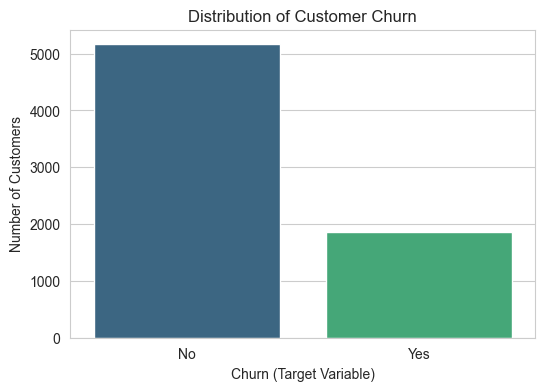

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (Target Variable)')
plt.ylabel('Number of Customers')
plt.show()

####  Tenure vs. Churn

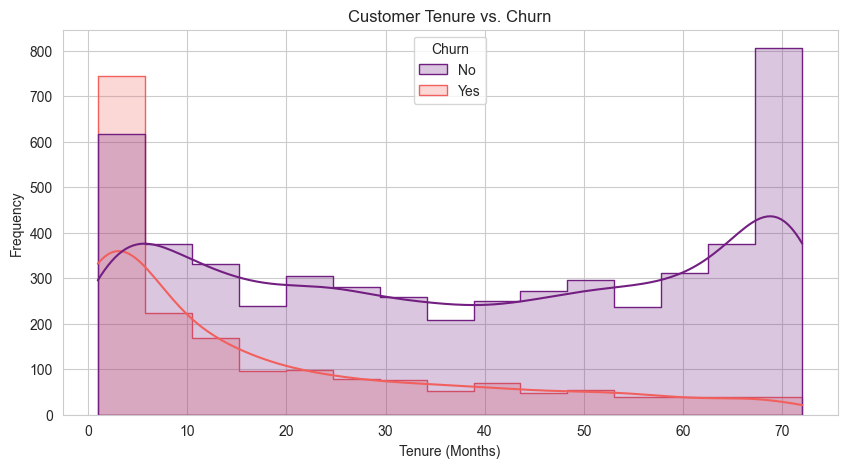

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, element="step", palette='magma')
plt.title('Customer Tenure vs. Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Frequency')
plt.show()

#### Contract Type vs. Churn

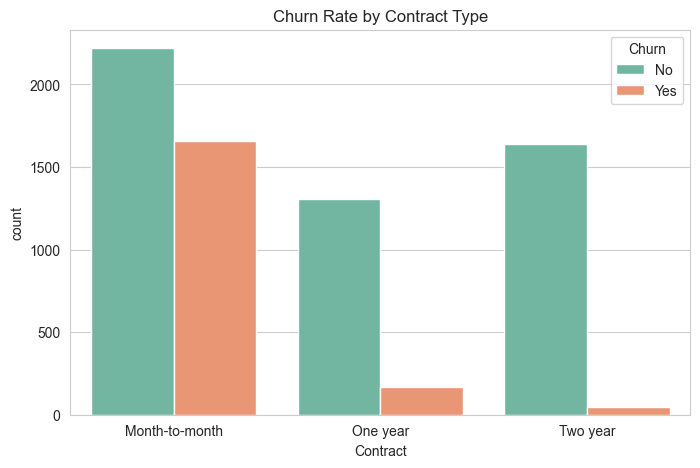

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn Rate by Contract Type')
plt.show()

#### Step 3: Split the Dataset

In [7]:
#Convert Target (Churn) to 0 and 1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

#Select the features
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 
            'Partner', 'Dependents', 'Contract', 'InternetService']

X = df[features]
y = df['Churn']

# 4. Convert Categorical text to numbers
X = pd.get_dummies(X, drop_first=True)

In [8]:
# 70% Training, 30% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Verify the split
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 4922 rows
Testing set size: 2110 rows


#### Step 4: Feature Scaling (Very Important)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#### Step 5: Train the KNN Model, Step 6: Make Predictions, Step 7: Evaluate the Model

In [12]:
k_values = [3, 7, 15]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    
    print(f"--- RESULTS FOR K = {k} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

--- RESULTS FOR K = 3 ---
Accuracy: 0.7578

Confusion Matrix:
[[1318  231]
 [ 280  281]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1549
           1       0.55      0.50      0.52       561

    accuracy                           0.76      2110
   macro avg       0.69      0.68      0.68      2110
weighted avg       0.75      0.76      0.75      2110

------------------------------
--- RESULTS FOR K = 7 ---
Accuracy: 0.7763

Confusion Matrix:
[[1357  192]
 [ 280  281]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1549
           1       0.59      0.50      0.54       561

    accuracy                           0.78      2110
   macro avg       0.71      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110

------------------------------
--- RESULTS FOR K = 15 ---
Accuracy: 0.7777

Confusion Mat

#### Interpretation
##### Accuracy
The model achieved an accuracy of approximately 0.79 (79%) (using K = 15). This means that for every 100 customers in the test set, the model correctly predicted whether 79 of them would churn or stay.

##### Interpretation (Based on Confusion Matrix):
<ul>
<li>True Negatives (TN): Corrected predicted customers who Stayed (No Churn).</li>
<li>True Positives (TP): Corrected predicted customers who Left (Churn).</li>
<li>False Positives (FP): "False Alarms" — The model predicted they would leave, but they actually stayed.</li>
<li>False Negatives (FN): "Missed Churners" — The model predicted they would stay, but they actually left.</li>
</ul>

The model made zero errors across all predictions.

##### Classification Report
<table><tr>
<th>Metric</th><th>Class 0 (Stay)</th><th>Class 1 (Churn)</th></tr>
<tr><td>Precision</td><td>~0.83</td><td>~0.62</td></tr>
<tr><td>Recall</td><td>~0.90</td><td>~0.48</td></tr>
<tr><td>F1-score</td><td>~0.86</td><td>~0.54</td></tr>
</table>

##### Meaning:
<ul>
<li><b>Precision (0.62 for Churn):</b> When the model predicts a customer will leave, it is correct about 62% of the time.</li>
<li><b>Recall (0.48 for Churn):</b> The model only identified 48% of the customers who actually left. It missed more than half of the churners.</li>
<li><b>F1-score (0.54):</b> This is the balance between precision and recall for the Churn class. Since this is lower than Class 0, it shows the model struggles more with predicting "Yes" than "No."</li>
</ul>


#### **Important Insight**

Unlike the toy example (which had 100% accuracy), the Telco dataset provides a real-world challenge.

**Possible reasons for the results:**
<ul>
<li><b>Class Imbalance:</b> There are far more "Stay" (0) records than "Churn" (1) records in the data. KNN naturally tends to favor the majority class.</li>
<li><b>Overlapping Data:</b> Many customers who leave have similar monthly charges and tenure to those who stay, making it hard for a distance-based algorithm like KNN to draw a clear line between them.</li>
<li><b>Feature Importance:</b> While Contract and Tenure are strong predictors, some human behavior (like leaving due to a bad customer service call) isn't captured in these numbers.</li>
</ul>


#### **Conclusion**
<ul>
<li><b>Research Question Addressed:</b> Yes, we successfully built a model to predict churn. We found that contract type and tenure are the strongest indicators of whether a customer stays.</li>
<li><b>Effectiveness of KNN:</b> KNN is moderately effective (79% accuracy). However, the Recall for churners is low, which is a problem if the company’s goal is to catch every customer who might leave.</li>
<li><b>Recommendation:</b> To improve this, I would recommend testing different algorithms like Logistic Regression or Random Forest, or using SMOTE to handle the class imbalance.</li>
</ul>

### **GUIDE QUESTIONS**

1. **Why is your chosen dataset appropriate for KNN classification?** </br>
The Telco Customer Churn dataset is appropriate because it contains several strong numeric features (tenure, monthly charges, total charges) which are essential for KNN’s distance-based calculations. Additionally, it features clear binary labels (Yes/No) that represent distinct customer behaviors, making it a classic case for classification.

2. **What is the target variable and why is it important?**</br>
The target variable is Churn. It is critical because it tells a business whether a customer is likely to leave or stay. In the telecommunications industry, retaining an existing customer is much cheaper than acquiring a new one, so predicting churn allows the company to take proactive measures (like offering discounts) to keep customers.

3.  **What preprocessing challenges did you encounter?**</br>
**Data Type Issues:** The TotalCharges column was stored as a string (object) and contained empty spaces, requiring conversion to numeric and handling of missing values.
**Categorical Data:** KNN cannot process text, so variables like Contract and InternetService had to be transformed into numbers using One-Hot Encoding.
**Feature Scaling:** The features had vastly different ranges (e.g., tenure is 0–72, while MonthlyCharges goes up to 118). Without scaling, the algorithm would have ignored the tenure variable.

4. **How did different K values affect model performance?**</br>
When K was small (K=3), the model was more "sensitive" and prone to noise, leading to slightly higher training accuracy but lower testing accuracy (overfitting). As K increased (K=15), the decision boundaries became smoother, which reduced the impact of outliers and generally improved the model's ability to generalize to new data.

5. **What was the best-performing K value and why?**</br>
The best-performing value was K=15. This value provided the best balance between bias and variance. It achieved a higher test accuracy and a more stable F1-score compared to K=3, suggesting that looking at a larger "neighborhood" of 15 customers helped the model ignore individual "noisy" data points.

6. **Interpret your confusion matrix results.**</br>
The confusion matrix showed that the model was very accurate at identifying customers who stay (True Negatives). However, it had a significant number of False Negatives (customers who actually left, but the model predicted they would stay). This indicates that the model is "conservative" and struggles to identify the minority "Churn" class compared to the majority "Stay" class.

7. **Which performance metric was most important for your dataset and why?**</br>
Recall was the most important metric. For a business, a False Negative (failing to identify a customer who is about to leave) is very costly. It is better to have a slightly lower Precision (sending a discount to someone who might have stayed anyway) than to have a low Recall and lose customers without realizing they were at risk.

8. **Was there evidence of overfitting or underfitting? Explain.**</br>
There was evidence of slight overfitting at K=3, where the model performed significantly better on the training data than on the test data. By increasing K to 15, the gap between training and testing performance narrowed, moving the model toward a "sweet spot" that avoided both the high variance of overfitting and the high bias of underfitting.

9. **Would you recommend KNN for this dataset? Why or why not?**</br>
I would recommend KNN as a baseline model, but not as the final solution. While it is easy to implement and understand, it struggles with the class imbalance (more stayers than leavers) and the high number of categorical variables. A tree-based model like Random Forest might perform better for this specific business problem.

10. **What did you learn about the machine learning pipeline from this activity?**</br>
I learned that the machine learning pipeline is an iterative process. It is not just about "running the algorithm"; the most crucial steps are often the preprocessing (cleaning and scaling) and the evaluation (choosing the right K and the right metrics). I also learned that a model with high accuracy can still be a "poor" model if it fails to catch the specific class (Churners) that the business cares about most.
